# 1. import required libs

In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

import os

# 2. Read Data 

In [332]:
df = pd.read_csv('data/cleaned_data/order_lv_cleaned.csv')

In [333]:
df.head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_state,total_price,total_frieght,item_count,target
0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29,RJ,58.90,13.29,1,1
1,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15,SP,239.90,19.93,1,8
2,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05,MG,199.00,17.87,1,6
3,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20,SP,12.99,12.79,1,4
4,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17,SP,199.90,18.14,1,13


In [334]:
df = df.rename(columns={'target': 'delivery_time'})

In [335]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96438 entries, 0 to 96437
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_purchase_timestamp       96438 non-null  str    
 1   order_approved_at              96438 non-null  str    
 2   order_delivered_carrier_date   96438 non-null  str    
 3   order_estimated_delivery_date  96438 non-null  str    
 4   customer_state                 96438 non-null  str    
 5   total_price                    96438 non-null  float64
 6   total_frieght                  96438 non-null  float64
 7   item_count                     96438 non-null  int64  
 8   delivery_time                  96438 non-null  int64  
dtypes: float64(2), int64(2), str(5)
memory usage: 6.6 MB


In [336]:
import pandas as pd

# =========================
# 1. Convert date columns
# =========================

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )


# =========================
# 2. Feature Engineering
# =========================

# --- Purchase features ---
df['purchase_hour'] = (
    df['order_purchase_timestamp'].dt.hour
)

df['purchase_day_of_week'] = (
    df['order_purchase_timestamp'].dt.dayofweek
)

df['purchase_month'] = (
    df['order_purchase_timestamp'].dt.month
)

df['purchase_is_weekend'] = (
    df['order_purchase_timestamp'].dt.dayofweek >= 5
).astype(int)


# --- Approval delay ---
df['approval_delay_hours'] = (
    df['order_approved_at']
    - df['order_purchase_timestamp']
).dt.total_seconds() / 3600


# --- Time from purchase to carrier ---
df['purchase_to_carrier_hours'] = (
    df['order_delivered_carrier_date']
    - df['order_purchase_timestamp']
).dt.total_seconds() / 3600


# --- Estimated time available from carrier to estimated delivery ---
df['estimated_delivery_window_days'] = (
    df['order_estimated_delivery_date']
    - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400


# --- Carrier handoff date features ---
df['carrier_hour'] = (
    df['order_delivered_carrier_date'].dt.hour
)

df['carrier_day_of_week'] = (
    df['order_delivered_carrier_date'].dt.dayofweek
)

df['carrier_month'] = (
    df['order_delivered_carrier_date'].dt.month
)

df['carrier_is_weekend'] = (
    df['order_delivered_carrier_date'].dt.dayofweek >= 5
).astype(int)


# =========================
# 3. Drop raw date columns
# =========================

df = df.drop([
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_estimated_delivery_date'
], axis=1)

In [337]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96438 entries, 0 to 96437
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_state                  96438 non-null  str    
 1   total_price                     96438 non-null  float64
 2   total_frieght                   96438 non-null  float64
 3   item_count                      96438 non-null  int64  
 4   delivery_time                   96438 non-null  int64  
 5   purchase_hour                   96438 non-null  int32  
 6   purchase_day_of_week            96438 non-null  int32  
 7   purchase_month                  96438 non-null  int32  
 8   purchase_is_weekend             96438 non-null  int64  
 9   approval_delay_hours            96438 non-null  float64
 10  purchase_to_carrier_hours       96438 non-null  float64
 11  estimated_delivery_window_days  96438 non-null  float64
 12  carrier_hour                    96438 non-n

In [338]:
df.head()

,customer_state,total_price,total_frieght,item_count,delivery_time,purchase_hour,purchase_day_of_week,purchase_month,purchase_is_weekend,approval_delay_hours,purchase_to_carrier_hours,estimated_delivery_window_days,carrier_hour,carrier_day_of_week,carrier_month,carrier_is_weekend
0,RJ,58.90,13.29,1,1,8,2,9,0,0.775833,153.587222,9.226204,18,1,9,0
1,SP,239.90,19.93,1,8,10,2,4,0,0.201944,195.698333,10.392361,14,3,5,0
2,MG,199.00,17.87,1,6,14,6,1,1,0.249722,46.054722,19.474444,12,1,1,0
3,SP,12.99,12.79,1,4,10,2,8,0,0.161944,51.456944,9.438889,13,4,8,0
4,SP,199.90,18.14,1,13,13,5,2,1,0.206111,283.805000,28.592951,9,3,2,0


In [339]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_price,96438.0,137.034021,209.080705,0.850000,45.900000,86.500000,149.900000,13440.000000
total_frieght,96438.0,22.783251,21.559920,0.000000,13.850000,17.170000,24.010000,1794.960000
item_count,96438.0,1.141977,0.538394,1.000000,1.000000,1.000000,1.000000,21.000000
delivery_time,96438.0,8.881416,8.745344,0.000000,4.000000,7.000000,12.000000,205.000000
purchase_hour,96438.0,14.773139,5.328801,0.000000,11.000000,15.000000,19.000000,23.000000
purchase_day_of_week,96438.0,2.756165,1.967079,0.000000,1.000000,3.000000,4.000000,6.000000
purchase_month,96438.0,6.031647,3.228519,1.000000,3.000000,6.000000,8.000000,12.000000
purchase_is_weekend,96438.0,0.229940,0.420796,0.000000,0.000000,0.000000,0.000000,1.000000
approval_delay_hours,96438.0,10.277504,20.535477,0.000000,0.215278,0.343333,14.517708,741.443611
purchase_to_carrier_hours,96438.0,77.421104,86.301594,-4109.098056,27.041181,52.819306,97.584444,3018.612500


In [340]:
df.max()

customer_state                            TO
total_price                          13440.0
total_frieght                        1794.96
item_count                                21
delivery_time                            205
purchase_hour                             23
purchase_day_of_week                       6
purchase_month                            12
purchase_is_weekend                        1
approval_delay_hours              741.443611
purchase_to_carrier_hours          3018.6125
estimated_delivery_window_days    192.434028
carrier_hour                              23
carrier_day_of_week                        6
carrier_month                             12
carrier_is_weekend                         1
dtype: object

In [341]:
(df['purchase_to_carrier_hours'] < 0).sum(), (df['estimated_delivery_window_days'] < 0).sum()

(np.int64(165), np.int64(465))

In [342]:
df = df[(df['purchase_to_carrier_hours'] >= 0) 
            & (df['estimated_delivery_window_days'] >= 0)]

In [343]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_price,95808.0,136.756316,208.136787,0.850000,45.900000,86.330000,149.900000,13440.000000
total_frieght,95808.0,22.791735,21.557281,0.000000,13.860000,17.180000,24.010000,1794.960000
item_count,95808.0,1.141951,0.537949,1.000000,1.000000,1.000000,1.000000,21.000000
delivery_time,95808.0,8.899299,8.727400,0.000000,4.000000,7.000000,12.000000,205.000000
purchase_hour,95808.0,14.775593,5.331893,0.000000,11.000000,15.000000,19.000000,23.000000
purchase_day_of_week,95808.0,2.758788,1.967917,0.000000,1.000000,3.000000,4.000000,6.000000
purchase_month,95808.0,6.026052,3.230711,1.000000,3.000000,6.000000,8.000000,12.000000
purchase_is_weekend,95808.0,0.230607,0.421224,0.000000,0.000000,0.000000,0.000000,1.000000
approval_delay_hours,95808.0,10.262925,20.368795,0.000000,0.215278,0.343056,14.518056,741.443611
purchase_to_carrier_hours,95808.0,75.494035,76.067756,0.008889,27.048056,52.660139,97.057917,1322.424722


In [344]:
purchase_hours_bins = [0, 6, 12, 18, 24]

purchase_hours_labels = ['0-6', '6-12', '12-18', '18-24']

df['purchase_hour_interval'] = pd.cut(
    df['purchase_hour'],
    bins=purchase_hours_bins,
    labels=purchase_hours_labels,
    include_lowest=True
)

In [345]:
df.head()

,customer_state,total_price,total_frieght,item_count,delivery_time,purchase_hour,purchase_day_of_week,purchase_month,purchase_is_weekend,approval_delay_hours,purchase_to_carrier_hours,estimated_delivery_window_days,carrier_hour,carrier_day_of_week,carrier_month,carrier_is_weekend,purchase_hour_interval
0,RJ,58.90,13.29,1,1,8,2,9,0,0.775833,153.587222,9.226204,18,1,9,0,6-12
1,SP,239.90,19.93,1,8,10,2,4,0,0.201944,195.698333,10.392361,14,3,5,0,6-12
2,MG,199.00,17.87,1,6,14,6,1,1,0.249722,46.054722,19.474444,12,1,1,0,12-18
3,SP,12.99,12.79,1,4,10,2,8,0,0.161944,51.456944,9.438889,13,4,8,0,6-12
4,SP,199.90,18.14,1,13,13,5,2,1,0.206111,283.805000,28.592951,9,3,2,0,12-18


In [346]:
delivery_analysis = (
    df.groupby('purchase_hour_interval')['delivery_time']
          .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
          .reset_index()
    )

delivery_analysis['percentage'] = (
      round((delivery_analysis['count'] / delivery_analysis['count'].sum()) * 100,1)
)

In [347]:
delivery_analysis

,purchase_hour_interval,count,mean,median,std,min,max,percentage
0,0-6,5042,9.114240,7.0,8.739481,0,132,5.3
1,6-12,26746,8.800419,7.0,8.542222,0,187,27.9
2,12-18,36636,8.869937,7.0,8.708144,0,205,38.2
3,18-24,27384,8.995581,7.0,8.926429,0,195,28.6


In [348]:
df.groupby('purchase_hour_interval')['delivery_time'].mean()

purchase_hour_interval
0-6      9.114240
6-12     8.800419
12-18    8.869937
18-24    8.995581
Name: delivery_time, dtype: float64

<Figure size 1000x600 with 0 Axes>

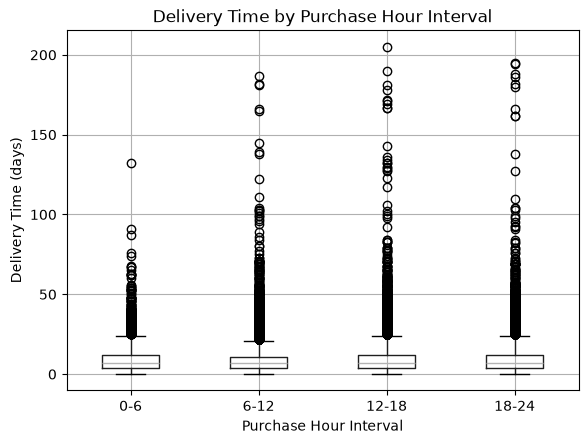

In [349]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column='delivery_time',
    by='purchase_hour_interval'
)

plt.title('Delivery Time by Purchase Hour Interval')
plt.suptitle('')
plt.xlabel('Purchase Hour Interval')
plt.ylabel('Delivery Time (days)')
plt.show()

<Figure size 1000x600 with 0 Axes>

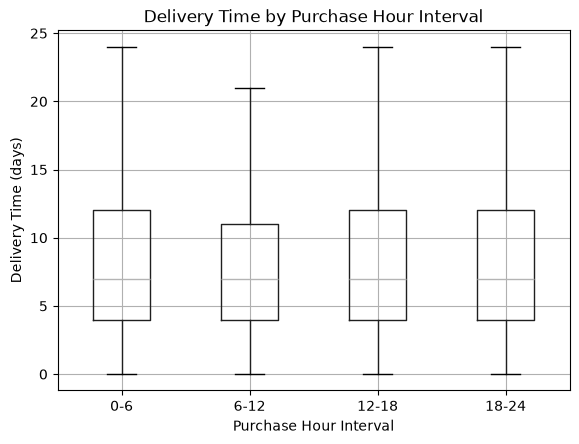

In [350]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column='delivery_time',
    by='purchase_hour_interval',
    showfliers=False
)

plt.title('Delivery Time by Purchase Hour Interval')
plt.suptitle('')
plt.xlabel('Purchase Hour Interval')
plt.ylabel('Delivery Time (days)')
plt.show()

In [351]:
df.columns

Index(['customer_state', 'total_price', 'total_frieght', 'item_count',
       'delivery_time', 'purchase_hour', 'purchase_day_of_week',
       'purchase_month', 'purchase_is_weekend', 'approval_delay_hours',
       'purchase_to_carrier_hours', 'estimated_delivery_window_days',
       'carrier_hour', 'carrier_day_of_week', 'carrier_month',
       'carrier_is_weekend', 'purchase_hour_interval'],
      dtype='str')

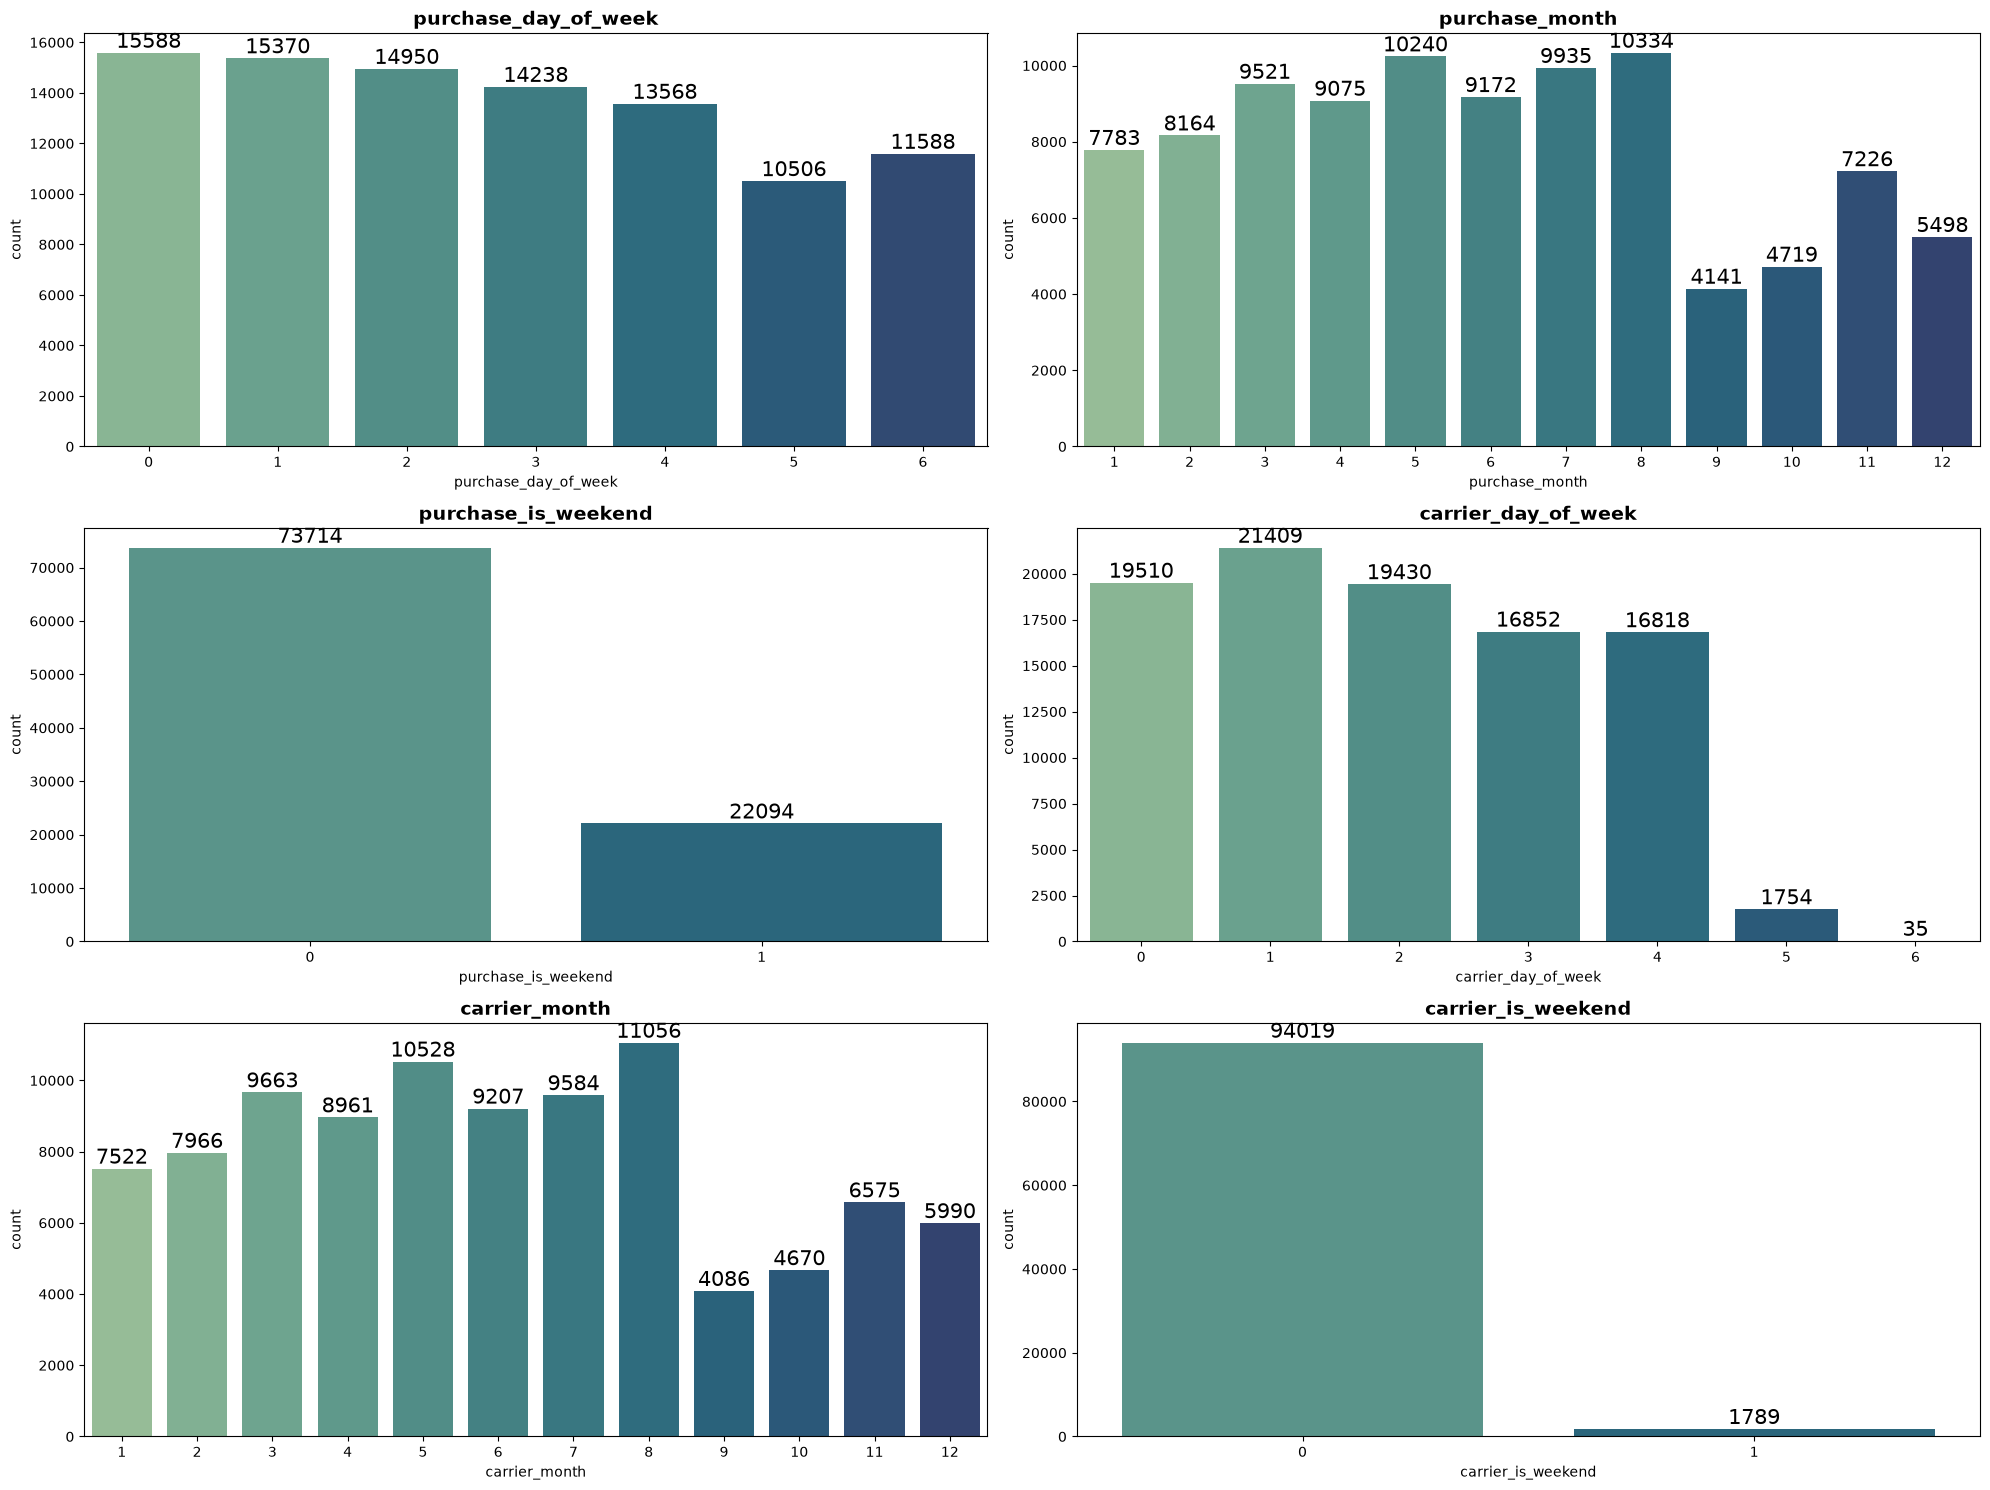

In [352]:
features = [
    'purchase_day_of_week',
    'purchase_month',
    'purchase_is_weekend',
    'carrier_day_of_week', 
    'carrier_month',
    'carrier_is_weekend'
]

fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.countplot(data=df, x=col, palette='crest', ax=axes[i])
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    
    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

os.makedirs('images',exist_ok=True)

fig.savefig('./images/123456.png')

del(features)

In [353]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

Shape: (95808, 17)

Data Types:
customer_state                         str
total_price                        float64
total_frieght                      float64
item_count                           int64
delivery_time                        int64
purchase_hour                        int32
purchase_day_of_week                 int32
purchase_month                       int32
purchase_is_weekend                  int64
approval_delay_hours               float64
purchase_to_carrier_hours          float64
estimated_delivery_window_days     float64
carrier_hour                         int32
carrier_day_of_week                  int32
carrier_month                        int32
carrier_is_weekend                   int64
purchase_hour_interval            category
dtype: object


In [354]:
print("\nMissing Values:")
print(df.isna().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
customer_state                    0
total_price                       0
total_frieght                     0
item_count                        0
delivery_time                     0
purchase_hour                     0
purchase_day_of_week              0
purchase_month                    0
purchase_is_weekend               0
approval_delay_hours              0
purchase_to_carrier_hours         0
estimated_delivery_window_days    0
carrier_hour                      0
carrier_day_of_week               0
carrier_month                     0
carrier_is_weekend                0
purchase_hour_interval            0
dtype: int64

Duplicate Rows:
0


In [355]:
df.describe(include='object').T

,count,unique,top,freq
customer_state,95808,27,SP,40085


In [356]:
print(f"delivery_time describtion: \n{df['delivery_time'].describe()}")

print("\ndelivery_time Skewness:",
      df['delivery_time'].skew())

print("\ndelivery_time Median:",
      df['delivery_time'].median())

delivery_time describtion: 
count    95808.000000
mean         8.899299
std          8.727400
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        205.000000
Name: delivery_time, dtype: float64

delivery_time Skewness: 4.486853781077168

delivery_time Median: 7.0


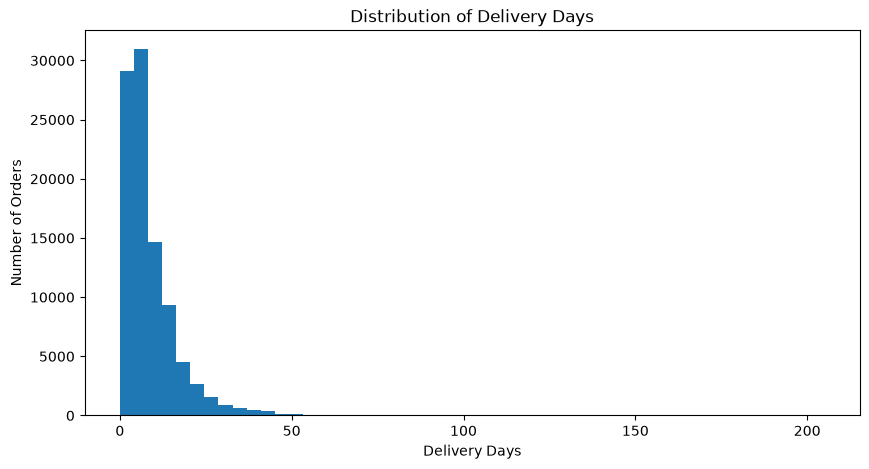

In [357]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['delivery_time'],
    bins=50
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')

plt.show()

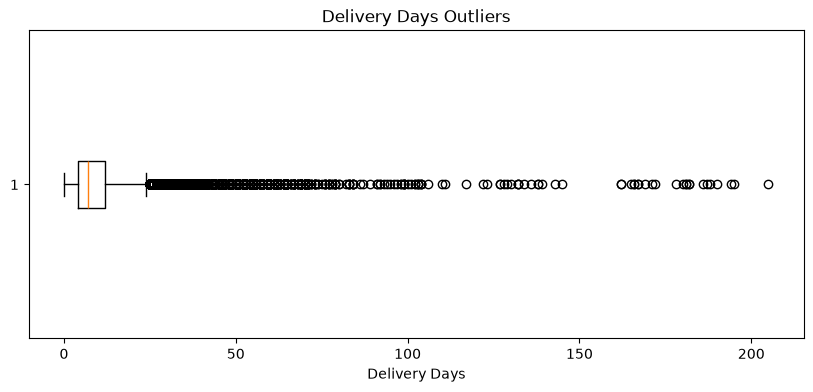

In [358]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df['delivery_time'],
    vert=False
)

plt.title('Delivery Days Outliers')
plt.xlabel('Delivery Days')

plt.show()

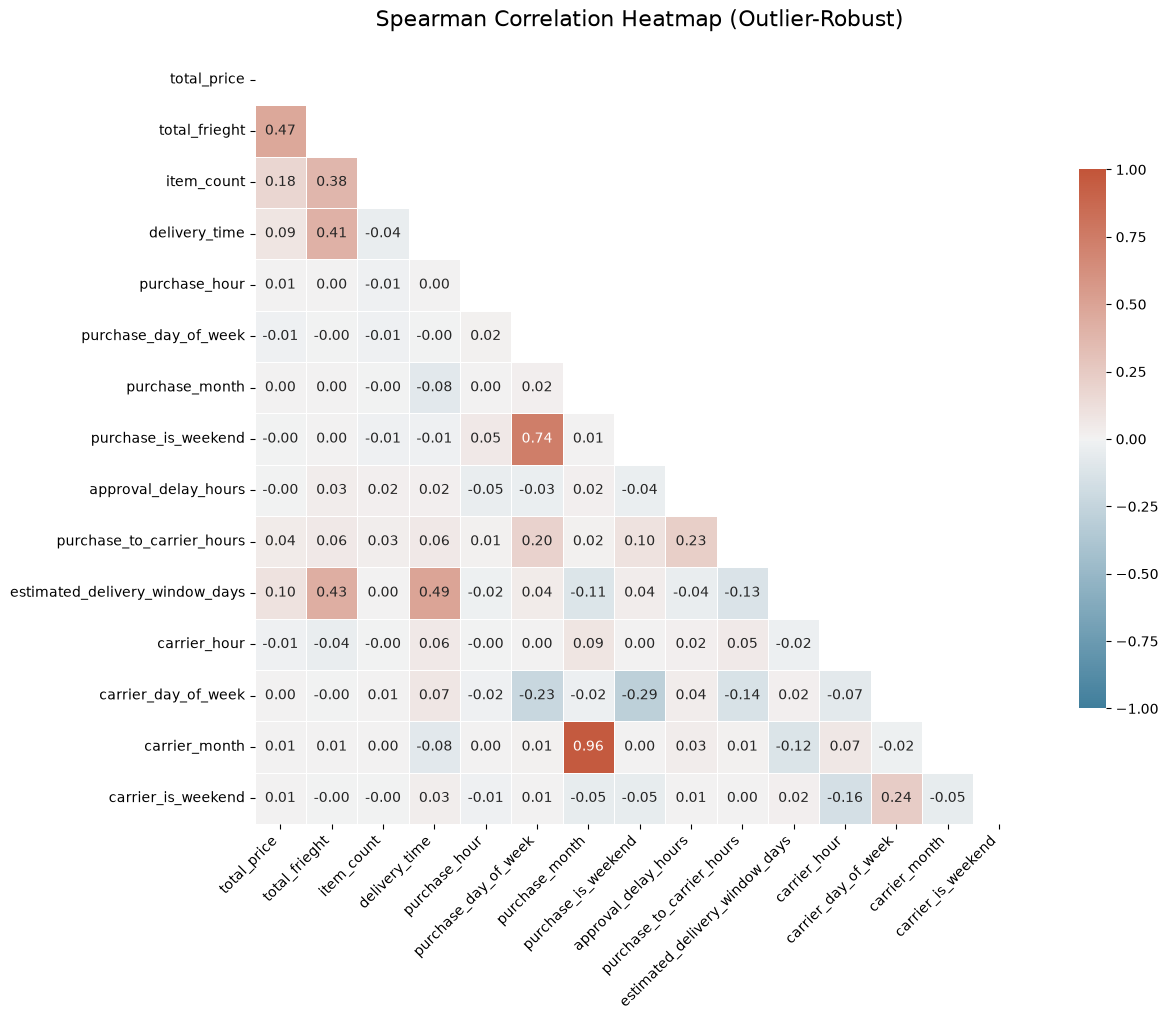

In [461]:
# 1. عزل المتغيرات الرقمية فقط لتجنب الأخطاء
numeric_df = df.select_dtypes(include=[np.number])

# 2. استخدام Spearman بدلاً من Pearson بسبب وجود Outliers
corr_matrix = numeric_df.corr(method='spearman')

# 3. إنشاء قناع (Mask) لإخفاء النصف العلوي المكرر من المصفوفة
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. إعداد أبعاد الرسم البياني (كبر الحجم إذا زادت المتغيرات)
plt.figure(figsize=(14, 10))

# 5. اختيار باليتة ألوان متباينة (أزرق للعكسي، أحمر للطردي، أبيض للصفر)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 6. رسم الـ Heatmap مع الخصائص الاحترافية
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmin=-1, vmax=1, center=0, # تثبيت مقياس الألوان من -1 إلى 1
    annot=True, 
    fmt=".2f",                 # الاكتفاء برقمين عشريين
    linewidths=.5,             # فصل المربعات بخطوط بيضاء دقيقة
    cbar_kws={"shrink": .7},   # تصغير شريط الألوان ليتناسب مع التصميم
    square=True                # جعل الخلايا مربعة تماماً
)

plt.title('Spearman Correlation Heatmap (Outlier-Robust)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')

plt.savefig(
    f'images/{col}_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [360]:
numeric_features = [
    'total_price',
    'total_frieght',
    'item_count',
    'purchase_hour',
    'purchase_day_of_week',
    'purchase_month',
    'purchase_is_weekend',
    'approval_delay_hours',
    'purchase_to_carrier_hours',
    'estimated_delivery_window_days',
    'carrier_hour',
    'carrier_day_of_week',
    'carrier_month',
    'carrier_is_weekend'
]

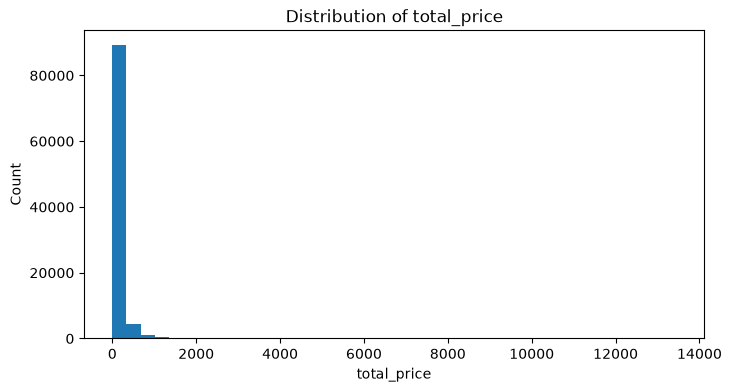

<Figure size 640x480 with 0 Axes>

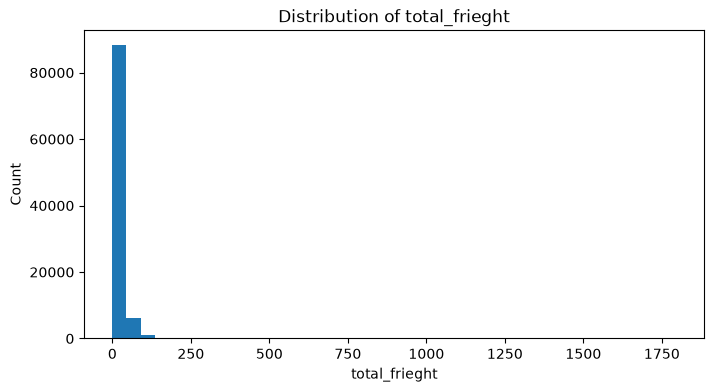

<Figure size 640x480 with 0 Axes>

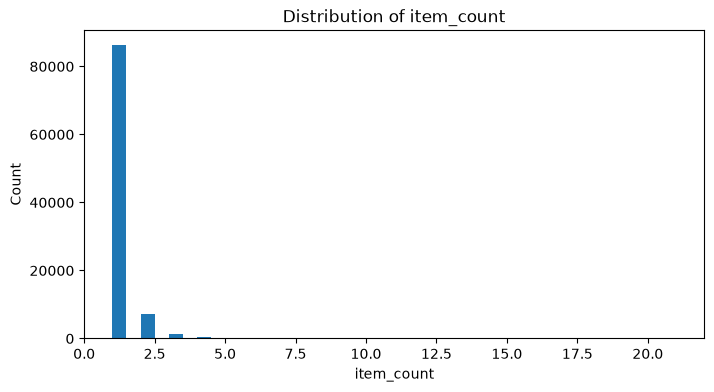

<Figure size 640x480 with 0 Axes>

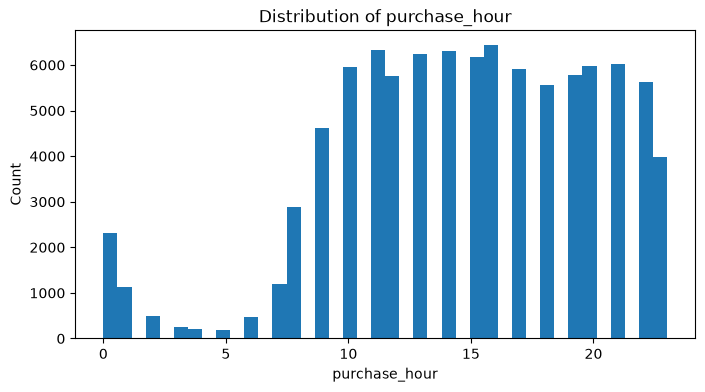

<Figure size 640x480 with 0 Axes>

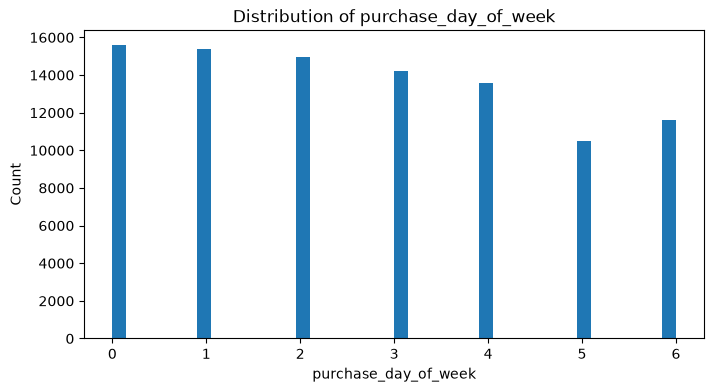

KeyError: 'purchase_day_of_month'

<Figure size 640x480 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [460]:
for col in numeric_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[col],
        bins=40
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.show()

    plt.savefig('images/correlation_matrix.png')

In [362]:
outlier_summary = []

for col in numeric_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary.append([
        col,
        Q1,
        Q3,
        lower,
        upper,
        outliers
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'feature',
        'Q1',
        'Q3',
        'lower_bound',
        'upper_bound',
        'outliers_count'
    ]
)

outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outliers_count
0,total_price,45.900000,149.900000,-110.100000,305.900000,7585
1,total_frieght,13.860000,24.010000,-1.365000,39.235000,9645
2,item_count,1.000000,1.000000,1.000000,1.000000,9562
3,purchase_hour,11.000000,19.000000,-1.000000,31.000000,0
4,purchase_day_of_week,1.000000,4.000000,-3.500000,8.500000,0
5,purchase_month,3.000000,8.000000,-4.500000,15.500000,0
6,purchase_is_weekend,0.000000,0.000000,0.000000,0.000000,22094
7,approval_delay_hours,0.215278,14.518056,-21.238889,35.972222,8870
8,purchase_to_carrier_hours,27.048056,97.057917,-77.966736,202.072708,4877
9,estimated_delivery_window_days,15.030058,25.619740,-0.854465,41.504262,1620


In [363]:
correlation_df = (
    df[numeric_features + ['delivery_time']]
    .corr()['delivery_time']
    .sort_values(ascending=False)
)

correlation_df

delivery_time                     1.000000
estimated_delivery_window_days    0.325311
total_frieght                     0.143636
carrier_day_of_week               0.049541
purchase_to_carrier_hours         0.041209
carrier_hour                      0.035426
total_price                       0.030522
carrier_is_weekend                0.025905
approval_delay_hours              0.010229
purchase_hour                     0.002985
purchase_day_of_week             -0.000719
purchase_is_weekend              -0.002561
item_count                       -0.034549
purchase_month                   -0.069912
carrier_month                    -0.071070
Name: delivery_time, dtype: float64

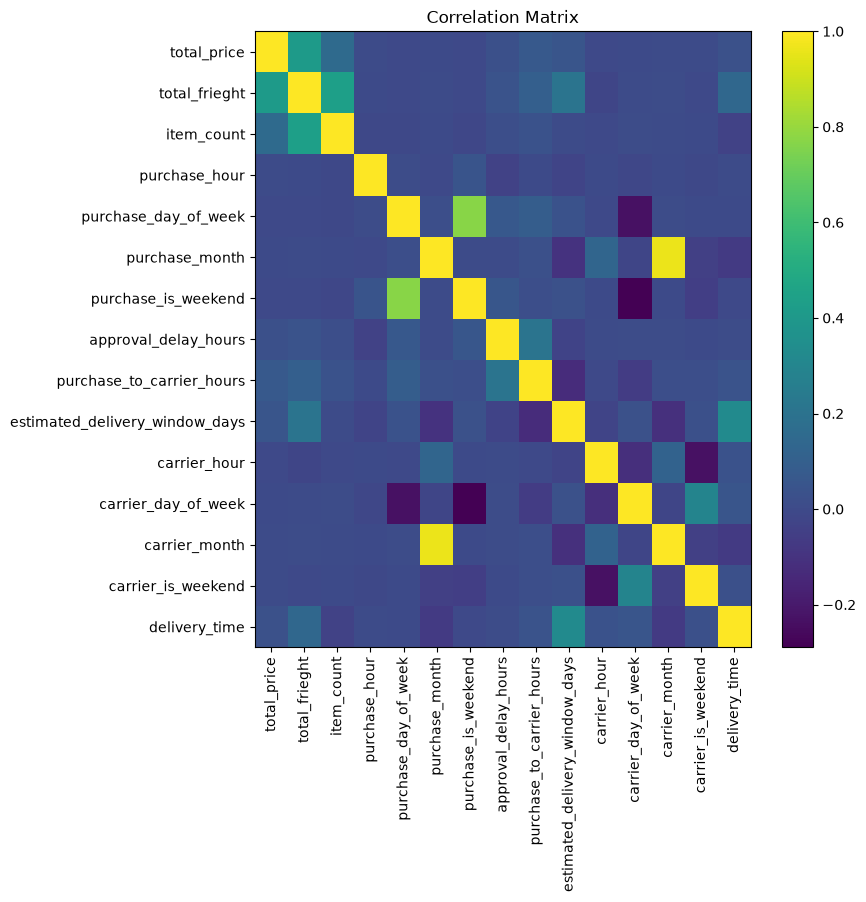

In [364]:
plt.figure(figsize=(8, 8))

plt.imshow(
    df[numeric_features + ['delivery_time']].corr(),
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(numeric_features) + 1),
    numeric_features + ['delivery_time'],
    rotation=90
)

plt.yticks(
    range(len(numeric_features) + 1),
    numeric_features + ['delivery_time']
)

plt.title('Correlation Matrix')

plt.show()

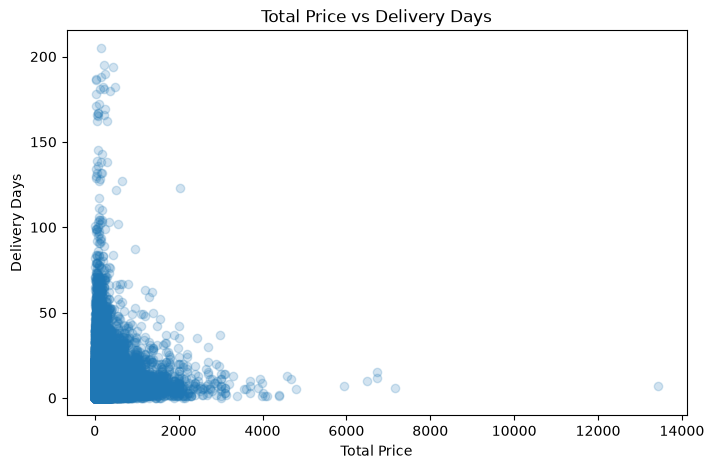

In [365]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['total_price'],
    df['delivery_time'],
    alpha=0.2
)

plt.xlabel('Total Price')
plt.ylabel('Delivery Days')
plt.title('Total Price vs Delivery Days')

plt.show()

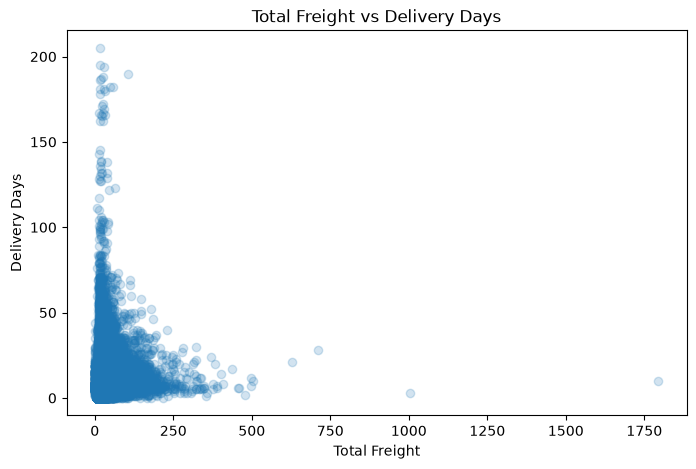

In [366]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['total_frieght'],
    df['delivery_time'],
    alpha=0.2
)

plt.xlabel('Total Freight')
plt.ylabel('Delivery Days')
plt.title('Total Freight vs Delivery Days')

plt.show()

In [367]:
item_delivery_time_df = (
    df
    .groupby('item_count')['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

item_delivery_time_df

,item_count,count,mean,median
0,1,86246,9.009450,7.0
1,2,7341,8.021114,6.0
2,3,1294,7.564915,6.0
3,4,492,7.869919,6.0
4,5,192,7.296875,6.0
5,6,186,6.704301,6.0
6,7,21,7.428571,6.0
7,8,8,6.250000,6.0
8,9,3,4.000000,3.0
9,10,8,6.000000,6.5


In [368]:
purchase_hour_df = (
    df
    .groupby('purchase_hour')['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

purchase_hour_df

,purchase_hour,count,mean,median
0,0,2309,9.327414,7.0
1,1,1123,9.133571,7.0
2,2,494,9.050607,7.0
3,3,258,8.709302,7.0
4,4,201,7.731343,6.0
5,5,181,8.204420,7.0
6,6,476,9.250000,7.0
7,7,1195,8.641841,7.0
8,8,2895,8.602763,7.0
9,9,4618,8.817670,7.0


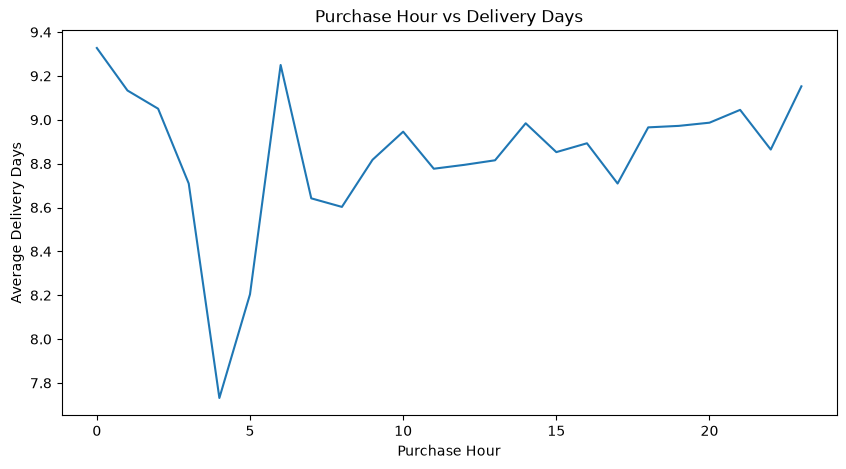

In [369]:
plt.figure(figsize=(10, 5))

plt.plot(
    purchase_hour_df['purchase_hour'],
    purchase_hour_df['mean']
)

plt.xlabel('Purchase Hour')
plt.ylabel('Average Delivery Days')
plt.title('Purchase Hour vs Delivery Days')

plt.show()

In [370]:
purchase_day_df = (
    df
    .groupby('purchase_day_of_week')['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

purchase_day_df

,purchase_day_of_week,count,mean,median
0,0,15588,8.852900,7.0
1,1,15370,8.821601,7.0
2,2,14950,9.023344,7.0
3,3,14238,8.935735,7.0
4,4,13568,8.932193,7.0
5,5,10506,9.054160,7.0
6,6,11588,8.681049,7.0


In [371]:
purchase_month_df = (
    df
    .groupby('purchase_month')['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

purchase_month_df

,purchase_month,count,mean,median
0,1,7783,9.837723,7.0
1,2,8164,12.127144,10.0
2,3,9521,11.654553,8.0
3,4,9075,8.842865,7.0
4,5,10240,8.221191,6.0
5,6,9172,7.063781,6.0
6,7,9935,6.675088,6.0
7,8,10334,6.000968,5.0
8,9,4141,8.155277,7.0
9,10,4719,7.823056,7.0


In [372]:
purchase_carrier_df = (
    df
    .groupby(
        pd.cut(
            df['purchase_to_carrier_hours'],
            bins=[0, 12, 24, 48, 72, 120, float('inf')]
        )
    )['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

purchase_carrier_df

,purchase_to_carrier_hours,count,mean,median
0,"(0.0, 12.0]",5341,7.992324,6.0
1,"(12.0, 24.0]",13639,8.001466,6.0
2,"(24.0, 48.0]",24011,8.779768,7.0
3,"(48.0, 72.0]",16285,9.149156,7.0
4,"(72.0, 120.0]",19997,9.205581,7.0
5,"(120.0, inf]",16535,9.489930,7.0


In [373]:
approval_df = (
    df
    .groupby(
        pd.cut(
            df['approval_delay_hours'],
            bins=[-float('inf'), 1, 6, 12, 24, 48, float('inf')]
        )
    )['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

approval_df

,approval_delay_hours,count,mean,median
0,"(-inf, 1.0]",61296,8.794832,7.0
1,"(1.0, 6.0]",5821,9.355609,7.0
2,"(6.0, 12.0]",2854,8.328662,6.0
3,"(12.0, 24.0]",9081,8.828213,7.0
4,"(24.0, 48.0]",11811,9.339260,7.0
5,"(48.0, inf]",4945,9.066127,7.0


In [374]:
estimated_window_df = (
    df
    .groupby(
        pd.cut(
            df['estimated_delivery_window_days'],
            bins=[0, 3, 5, 7, 10, 15, 20, float('inf')]
        )
    )['delivery_time']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

estimated_window_df

,estimated_delivery_window_days,count,mean,median
0,"(0.0, 3.0]",910,2.643956,1.0
1,"(3.0, 5.0]",803,2.988792,2.0
2,"(5.0, 7.0]",2207,3.171726,2.0
3,"(7.0, 10.0]",5499,3.317330,2.0
4,"(10.0, 15.0]",14424,5.217069,4.0
5,"(15.0, 20.0]",20717,8.297244,6.0
6,"(20.0, inf]",51248,11.228360,9.0


In [375]:
state_delivery_time_df = (
    df
    .groupby('customer_state')['delivery_time']
    .agg(
        orders_count='count',
        mean_delivery_days='mean',
        median_delivery_days='median'
    )
    .sort_values(
        'mean_delivery_days',
        ascending=False
    )
    .reset_index()
)

state_delivery_time_df

,customer_state,orders_count,mean_delivery_days,median_delivery_days
0,RR,41,25.219512,22.0
1,AP,67,23.208955,21.0
2,AM,145,23.103448,23.0
3,AL,397,20.609572,18.0
4,PA,943,19.846235,17.0
5,MA,711,17.599156,15.0
6,SE,334,17.520958,14.0
7,CE,1277,17.494910,14.0
8,AC,80,17.175000,15.0
9,PB,517,16.444874,14.0


In [376]:
delivery_time_correlation = (
    df
    .corr(numeric_only=True)['delivery_time']
    .drop('delivery_time')
    .sort_values(
        key=abs,
        ascending=False
    )
)

delivery_time_correlation

estimated_delivery_window_days    0.325311
total_frieght                     0.143636
carrier_month                    -0.071070
purchase_month                   -0.069912
carrier_day_of_week               0.049541
purchase_to_carrier_hours         0.041209
carrier_hour                      0.035426
item_count                       -0.034549
total_price                       0.030522
carrier_is_weekend                0.025905
approval_delay_hours              0.010229
purchase_hour                     0.002985
purchase_is_weekend              -0.002561
purchase_day_of_week             -0.000719
Name: delivery_time, dtype: float64

In [377]:
unique_values = (
    df
    .nunique()
    .sort_values()
)

unique_values

carrier_is_weekend                    2
purchase_is_weekend                   2
purchase_hour_interval                4
purchase_day_of_week                  7
carrier_day_of_week                   7
carrier_month                        12
purchase_month                       12
item_count                           17
carrier_hour                         24
purchase_hour                        24
customer_state                       27
delivery_time                       136
total_price                        7460
total_frieght                      7586
approval_delay_hours              32460
estimated_delivery_window_days    79608
purchase_to_carrier_hours         86744
dtype: int64

In [378]:
print("Negative delivery_time:",
      (df['delivery_time'] < 0).sum())

print("Zero delivery_time:",
      (df['delivery_time'] == 0).sum())

print("Infinite values:",
      df
      .isin([float('inf'), -float('inf')])
      .sum()
      .sum())

Negative delivery_time: 0
Zero delivery_time: 2647
Infinite values: 0


In [379]:
print(
    df[
        numeric_features + ['delivery_time']
    ].isna().sum()
)

total_price                       0
total_frieght                     0
item_count                        0
purchase_hour                     0
purchase_day_of_week              0
purchase_month                    0
purchase_is_weekend               0
approval_delay_hours              0
purchase_to_carrier_hours         0
estimated_delivery_window_days    0
carrier_hour                      0
carrier_day_of_week               0
carrier_month                     0
carrier_is_weekend                0
delivery_time                     0
dtype: int64


In [380]:
eda_summary = []

for col in numeric_features:

    eda_summary.append({
        'feature': col,
        'dtype': df[col].dtype,
        'missing': df[col].isna().sum(),
        'unique': df[col].nunique(),
        'mean': df[col].mean(),
        'median': df[col].median(),
        'std': df[col].std(),
        'min': df[col].min(),
        'max': df[col].max(),
        'skewness': df[col].skew(),
        'correlation_with_delivery_time':
            df[col].corr(
                df['delivery_time']
            )
    })

eda_summary_df = pd.DataFrame(eda_summary)

eda_summary_df.sort_values(
    'correlation_with_delivery_time',
    key=abs,
    ascending=False
)

,feature,dtype,missing,unique,mean,median,std,min,max,skewness,correlation_with_delivery_time
9,estimated_delivery_window_days,float64,0,79608,20.629960,20.295984,8.548081,0.008843,148.101632,0.770326,0.325311
1,total_frieght,float64,0,7586,22.791735,17.180000,21.557281,0.000000,1794.960000,12.318467,0.143636
12,carrier_month,int32,0,12,6.047345,6.000000,3.220943,1.000000,12.000000,0.215086,-0.071070
5,purchase_month,int32,0,12,6.026052,6.000000,3.230711,1.000000,12.000000,0.211668,-0.069912
11,carrier_day_of_week,int32,0,7,1.952624,2.000000,1.443759,0.000000,6.000000,0.180005,0.049541
8,purchase_to_carrier_hours,float64,0,86744,75.494035,52.660139,76.067756,0.008889,1322.424722,3.444269,0.041209
10,carrier_hour,int32,0,24,15.106025,15.000000,5.163739,0.000000,23.000000,-0.886344,0.035426
2,item_count,int64,0,17,1.141951,1.000000,0.537949,1.000000,21.000000,7.580843,-0.034549
0,total_price,float64,0,7460,136.756316,86.330000,208.136787,0.850000,13440.000000,9.964790,0.030522
13,carrier_is_weekend,int64,0,2,0.018673,0.000000,0.135367,0.000000,1.000000,7.111579,0.025905


In [381]:
drop_cols = [
    'carrier_month',
    'carrier_hour',
    'carrier_day_of_week',
    'carrier_is_weekend',
    'purchase_to_carrier_hours',
    'approval_delay_hours'
]

df_cleaned = df.drop(columns=drop_cols).copy()

In [398]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder,LabelEncoder

from sklearn.model_selection import GridSearchCV

In [383]:
X = df_cleaned.drop("delivery_time",axis=1)
Y = df_cleaned['delivery_time']

In [384]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [385]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((76646, 10), (19162, 10), (76646,), (19162,))

In [386]:
x_train[:1]

,customer_state,total_price,total_frieght,item_count,purchase_hour,purchase_day_of_week,purchase_month,purchase_is_weekend,estimated_delivery_window_days,purchase_hour_interval
55303,MG,71.8,31.12,2,19,5,3,1,16.599988,18-24


In [387]:
y_train[1]

np.int64(8)

In [413]:
def handle_cat_features():
    X = df_cleaned.drop("delivery_time",axis=1)
    Y = df_cleaned['delivery_time']

    x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


    encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

    state_train = encoder.fit_transform(x_train[['customer_state','purchase_hour_interval']])

    state_test = encoder.transform(x_test[['customer_state','purchase_hour_interval']])

    state_train_df = pd.DataFrame(state_train,
    columns=encoder.get_feature_names_out(['customer_state','purchase_hour_interval']),
    index=x_train.index)

    state_test_df = pd.DataFrame(state_test,
    columns=encoder.get_feature_names_out(['customer_state','purchase_hour_interval']),
    index=x_test.index)

    x_train = pd.concat([x_train.drop(['customer_state','purchase_hour_interval'],axis=1),state_train_df],axis=1)

    x_test = pd.concat([x_test.drop(['customer_state','purchase_hour_interval'],axis=1),state_test_df],axis=1)

    return x_train,x_test,y_train,y_test

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

state_train = encoder.fit_transform(x_train[['customer_state','purchase_hour_interval']])

state_test = encoder.transform(x_test[['customer_state','purchase_hour_interval']])

In [389]:
type(state_train)

numpy.ndarray

In [390]:
encoder.get_feature_names_out(['customer_state','purchase_hour_interval'])

array(['customer_state_AC', 'customer_state_AL', 'customer_state_AM',
       'customer_state_AP', 'customer_state_BA', 'customer_state_CE',
       'customer_state_DF', 'customer_state_ES', 'customer_state_GO',
       'customer_state_MA', 'customer_state_MG', 'customer_state_MS',
       'customer_state_MT', 'customer_state_PA', 'customer_state_PB',
       'customer_state_PE', 'customer_state_PI', 'customer_state_PR',
       'customer_state_RJ', 'customer_state_RN', 'customer_state_RO',
       'customer_state_RR', 'customer_state_RS', 'customer_state_SC',
       'customer_state_SE', 'customer_state_SP', 'customer_state_TO',
       'purchase_hour_interval_0-6', 'purchase_hour_interval_12-18',
       'purchase_hour_interval_18-24', 'purchase_hour_interval_6-12'],
      dtype=object)

In [391]:
state_train_df = pd.DataFrame(state_train,
columns=encoder.get_feature_names_out(['customer_state','purchase_hour_interval']),
index=x_train.index)

state_test_df = pd.DataFrame(state_test,
columns=encoder.get_feature_names_out(['customer_state','purchase_hour_interval']),
index=x_test.index)

In [392]:
x_train = pd.concat([x_train.drop(['customer_state','purchase_hour_interval'],axis=1),state_train_df],axis=1)

x_test = pd.concat([x_test.drop(['customer_state','purchase_hour_interval'],axis=1),state_test_df],axis=1)

In [393]:
x_train.head()

,total_price,total_frieght,item_count,purchase_hour,purchase_day_of_week,purchase_month,purchase_is_weekend,estimated_delivery_window_days,customer_state_AC,customer_state_AL,...,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,purchase_hour_interval_0-6,purchase_hour_interval_12-18,purchase_hour_interval_18-24,purchase_hour_interval_6-12
55303,71.80,31.12,2,19,5,3,1,16.599988,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
70876,98.00,17.97,1,19,3,9,0,24.210150,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
29718,10.80,8.27,1,15,6,12,1,31.007894,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2786,86.90,12.11,1,23,0,11,0,15.120278,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
23647,103.97,25.04,1,11,3,5,0,14.560833,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [394]:
df.columns

Index(['customer_state', 'total_price', 'total_frieght', 'item_count',
       'delivery_time', 'purchase_hour', 'purchase_day_of_week',
       'purchase_month', 'purchase_is_weekend', 'approval_delay_hours',
       'purchase_to_carrier_hours', 'estimated_delivery_window_days',
       'carrier_hour', 'carrier_day_of_week', 'carrier_month',
       'carrier_is_weekend', 'purchase_hour_interval'],
      dtype='str')

In [400]:
model_decisiontree = DecisionTreeRegressor(random_state=42)

model_decisiontree.fit(x_train,y_train)

y_pred = model_decisiontree.predict(x_test)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_leaf": [1, 5, 10, 20, 50]
}

grid = GridSearchCV(
    estimator=model_decisiontree,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbo

In [401]:
y_pred = grid.predict(x_test)

In [402]:
print(f"MAE: {mae(y_test,y_pred)}")

print(f"\nRMSE: {rmse(y_test,y_pred)}")

print(f"\nR2-Score: {r2_score(y_test,y_pred)}")

MAE: 4.293973739336282

RMSE: 7.2850950335496565

R2-Score: 0.2920672958324948


In [397]:
y_train_pred = model_decisiontree.predict(x_train)

print("Train MAE:", mae(y_train, y_train_pred))
print("Train R2:", r2_score(y_train, y_train_pred))

print("Test MAE:", mae(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train MAE: 4.34114174831597
Train R2: 0.2779361511052755
Test MAE: 4.3190764410958336
Test R2: 0.2901778138431287


In [403]:
depths = [3, 5, 7, 10, 15, 20, 25]

for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=10,
        random_state=42
    )
    
    model.fit(x_train, y_train)
    
    pred = model.predict(x_test)
    
    print(
        f"depth={depth:2} | "
        f"MAE={mae(y_test, pred):.3f} | "
        f"RMSE={rmse(y_test, pred):.3f} | "
        f"R2={r2_score(y_test, pred):.3f}"
    )

depth= 3 | MAE=4.685 | RMSE=7.698 | R2=0.210
depth= 5 | MAE=4.444 | RMSE=7.448 | R2=0.260
depth= 7 | MAE=4.348 | RMSE=7.353 | R2=0.279
depth=10 | MAE=4.354 | RMSE=7.398 | R2=0.270
depth=15 | MAE=4.442 | RMSE=7.512 | R2=0.247
depth=20 | MAE=4.571 | RMSE=7.651 | R2=0.219
depth=25 | MAE=4.640 | RMSE=7.747 | R2=0.199


In [404]:
param_grid = {
    "max_depth": [5, 6, 7, 8, 9, 10],
    "min_samples_leaf": [10, 20, 30, 50, 75]
}

In [405]:
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(-grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 75}
4.31576131653158


In [406]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test MAE:", mae(y_test, y_pred))
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

Test MAE: 4.284775303319006
Test RMSE: 7.267837482682285
Test R2: 0.29541734522654084


In [407]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(x_train, y_train)

y_pred = model_rf.predict(x_test)

print("MAE:", mae(y_test, y_pred))
print("RMSE:", rmse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4.2300472428318034
RMSE: 7.213400318887894
R2: 0.3059326704241805


In [408]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(x_train, y_train)

y_pred = model_gb.predict(x_test)

print("MAE:", mae(y_test, y_pred))
print("RMSE:", rmse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4.244292138797028
RMSE: 7.214949642266198
R2: 0.3056344892129169


### LinearRegression
### Lasso
### Ridge
### Elastic Net

In [409]:
X.head()

,customer_state,total_price,total_frieght,item_count,purchase_hour,purchase_day_of_week,purchase_month,purchase_is_weekend,estimated_delivery_window_days,purchase_hour_interval
0,RJ,58.90,13.29,1,8,2,9,0,9.226204,6-12
1,SP,239.90,19.93,1,10,2,4,0,10.392361,6-12
2,MG,199.00,17.87,1,14,6,1,1,19.474444,12-18
3,SP,12.99,12.79,1,10,2,8,0,9.438889,6-12
4,SP,199.90,18.14,1,13,5,2,1,28.592951,12-18


In [411]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
total_price,95808.0,136.756316,208.136787,0.850000,45.900000,86.330000,149.90000,13440.000000
total_frieght,95808.0,22.791735,21.557281,0.000000,13.860000,17.180000,24.01000,1794.960000
item_count,95808.0,1.141951,0.537949,1.000000,1.000000,1.000000,1.00000,21.000000
delivery_time,95808.0,8.899299,8.727400,0.000000,4.000000,7.000000,12.00000,205.000000
purchase_hour,95808.0,14.775593,5.331893,0.000000,11.000000,15.000000,19.00000,23.000000
purchase_day_of_week,95808.0,2.758788,1.967917,0.000000,1.000000,3.000000,4.00000,6.000000
purchase_month,95808.0,6.026052,3.230711,1.000000,3.000000,6.000000,8.00000,12.000000
purchase_is_weekend,95808.0,0.230607,0.421224,0.000000,0.000000,0.000000,0.00000,1.000000
estimated_delivery_window_days,95808.0,20.629960,8.548081,0.008843,15.030058,20.295984,25.61974,148.101632


In [414]:
x_train,x_test,y_train,y_test = handle_cat_features()

In [415]:
x_train.columns

Index(['total_price', 'total_frieght', 'item_count', 'purchase_hour',
       'purchase_day_of_week', 'purchase_month', 'purchase_is_weekend',
       'estimated_delivery_window_days', 'customer_state_AC',
       'customer_state_AL', 'customer_state_AM', 'customer_state_AP',
       'customer_state_BA', 'customer_state_CE', 'customer_state_DF',
       'customer_state_ES', 'customer_state_GO', 'customer_state_MA',
       'customer_state_MG', 'customer_state_MS', 'customer_state_MT',
       'customer_state_PA', 'customer_state_PB', 'customer_state_PE',
       'customer_state_PI', 'customer_state_PR', 'customer_state_RJ',
       'customer_state_RN', 'customer_state_RO', 'customer_state_RR',
       'customer_state_RS', 'customer_state_SC', 'customer_state_SE',
       'customer_state_SP', 'customer_state_TO', 'purchase_hour_interval_0-6',
       'purchase_hour_interval_12-18', 'purchase_hour_interval_18-24',
       'purchase_hour_interval_6-12'],
      dtype='str')

In [416]:
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
total_price,76646.0,136.609925,206.347522,0.850000,45.900000,86.250000,149.900000,13440.000000
total_frieght,76646.0,22.728042,20.550160,0.000000,13.850000,17.160000,23.980000,711.330000
item_count,76646.0,1.142538,0.542484,1.000000,1.000000,1.000000,1.000000,21.000000
purchase_hour,76646.0,14.777288,5.330629,0.000000,11.000000,15.000000,19.000000,23.000000
purchase_day_of_week,76646.0,2.759531,1.967731,0.000000,1.000000,3.000000,4.000000,6.000000
purchase_month,76646.0,6.020601,3.229367,1.000000,3.000000,6.000000,8.000000,12.000000
purchase_is_weekend,76646.0,0.230488,0.421148,0.000000,0.000000,0.000000,0.000000,1.000000
estimated_delivery_window_days,76646.0,20.605531,8.544315,0.008843,15.003524,20.288802,25.523877,148.101632
customer_state_AC,76646.0,0.000809,0.028430,0.000000,0.000000,0.000000,0.000000,1.000000
customer_state_AL,76646.0,0.004149,0.064279,0.000000,0.000000,0.000000,0.000000,1.000000


In [425]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = [
    'total_price',
    'total_frieght',
    'item_count',
    'purchase_hour',
    'purchase_day_of_week',
    'purchase_month',
    'estimated_delivery_window_days'
]

x_train_scaled = scaler.fit_transform(
    x_train[numeric_features]
)

x_test_scaled = scaler.transform(
    x_test[numeric_features]
)

In [428]:
x_train_scaled_df = pd.DataFrame(
    x_train_scaled,
    columns=numeric_features,
    index=x_train.index
)

x_test_scaled_df = pd.DataFrame(
    x_test_scaled,
    columns=numeric_features,
    index=x_test.index
)

In [429]:
x_train = pd.concat(
    [
        x_train.drop(columns=numeric_features),
        x_train_scaled_df
    ],
    axis=1
)

In [430]:
x_test = pd.concat(
    [
        x_test.drop(columns=numeric_features),
        x_test_scaled_df
    ],
    axis=1
)

In [433]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()

model_linear.fit(x_train,y_train)

y_pred = model_linear.predict(x_test)

In [ ]:
print(f"MAE: {mae(y_test,y_pred)}")

print(f"\nRMSE: {rmse(y_test,y_pred)}")

print(f"\nR2-Score: {r2_score(y_test,y_pred)}")



MAE: 4.645844606986142

RMSE: 7.609411907831685

R2-Score: 0.22763298175586733


In [436]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# 1) X and y
# =========================

X = df_cleaned.drop("delivery_time", axis=1)
y = df_cleaned["delivery_time"]


# =========================
# 2) Train / Test Split
# =========================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================
# 3) Feature Types
# =========================

categorical_features = [
    "customer_state",
    "purchase_hour_interval"
]

numeric_features = [
    "total_price",
    "total_frieght",
    "item_count",
    "purchase_hour",
    "purchase_day_of_week",
    "purchase_month",
    "purchase_is_weekend",
    "estimated_delivery_window_days"
]


# =========================
# 4) Preprocessing
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# =========================
# 5) Fit + Transform Train
# =========================

x_train_processed = preprocessor.fit_transform(x_train)


# =========================
# 6) Transform Test
# =========================

x_test_processed = preprocessor.transform(x_test)


# =========================
# 7) Linear Regression Model
# =========================

model = LinearRegression()


# =========================
# 8) Training
# =========================

model.fit(
    x_train_processed,
    y_train
)


# =========================
# 9) Prediction
# =========================

y_pred = model.predict(x_test_processed)


# =========================
# 10) Test Evaluation
# =========================

print("Test MAE :", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R2  :", r2_score(y_test, y_pred))


# =========================
# 11) Train Evaluation
# =========================

y_train_pred = model.predict(x_train_processed)

print("\nTrain MAE:", mean_absolute_error(y_train, y_train_pred))
print("Train R2 :", r2_score(y_train, y_train_pred))

Test MAE : 4.645844606986141
Test RMSE: 7.609411907831684
Test R2  : 0.22763298175586755

Train MAE: 4.639188964998827
Train R2 : 0.2196069082058386


In [441]:
# ==========================================
# Gradient Boosting + XGBoost Regression
# ==========================================

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


# ==========================================
# 1) X and y
# ==========================================

X = df_cleaned.drop(columns=["delivery_time"])
y = df_cleaned["delivery_time"]


# ==========================================
# 2) Train / Test Split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================================
# 3) Define feature types
# ==========================================

categorical_features = [
    "customer_state",
    "purchase_hour_interval"
]

numeric_features = [
    "total_price",
    "total_frieght",
    "item_count",
    "purchase_hour",
    "purchase_day_of_week",
    "purchase_month",
    "purchase_is_weekend",
    "estimated_delivery_window_days"
]


# ==========================================
# 4) Preprocessing
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ==========================================
# 5) Fit preprocessing on TRAIN only
# ==========================================

x_train_processed = preprocessor.fit_transform(x_train)


# ==========================================
# 6) Transform TEST
# ==========================================

x_test_processed = preprocessor.transform(x_test)


# ==========================================
# 7) Gradient Boosting Regressor
# ==========================================

model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(
    x_train_processed,
    y_train
)

y_pred_gb = model_gb.predict(
    x_test_processed
)


# ==========================================
# 8) Evaluate Gradient Boosting
# ==========================================

print("========== Gradient Boosting ==========")

print(
    "MAE :",
    mean_absolute_error(y_test, y_pred_gb)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred_gb))
)

print(
    "R2  :",
    r2_score(y_test, y_pred_gb)
)


# ==========================================
# 9) XGBoost Regressor
# ==========================================

model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    x_train_processed,
    y_train
)

y_pred_xgb = model_xgb.predict(
    x_test_processed
)


# ==========================================
# 10) Evaluate XGBoost
# ==========================================

print("\n========== XGBoost ==========")

print(
    "MAE :",
    mean_absolute_error(y_test, y_pred_xgb)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred_xgb))
)

print(
    "R2  :",
    r2_score(y_test, y_pred_xgb)
)

========== Gradient Boosting ==========
MAE : 4.244256180075343
RMSE: 7.214936426506926
R2  : 0.30563703297537914

========== XGBoost ==========
MAE : 4.146077632904053
RMSE: 7.117551959658426
R2  : 0.32425498962402344


In [442]:
# ==========================================
# XGBoost Hyperparameter Tuning
# ==========================================

import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ==========================================
# 1) Base XGBoost Model
# ==========================================

model_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


# ==========================================
# 2) Parameters to Search
# ==========================================

param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}


# ==========================================
# 3) GridSearchCV
# ==========================================

grid = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(
    x_train_processed,
    y_train
)


# ==========================================
# 4) Best Parameters
# ==========================================

print("\n========== Best Parameters ==========")
print(grid.best_params_)

print("\nBest CV MAE:")
print(-grid.best_score_)


# ==========================================
# 5) Best Model
# ==========================================

best_xgb = grid.best_estimator_


# ==========================================
# 6) Test Prediction
# ==========================================

y_pred_xgb = best_xgb.predict(
    x_test_processed
)


# ==========================================
# 7) Test Evaluation
# ==========================================

print("\n========== XGBoost Test Evaluation ==========")

test_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

test_r2 = r2_score(
    y_test,
    y_pred_xgb
)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2  :", test_r2)


# ==========================================
# 8) Train Evaluation
# ==========================================

y_train_pred_xgb = best_xgb.predict(
    x_train_processed
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred_xgb
)

train_r2 = r2_score(
    y_train,
    y_train_pred_xgb
)

print("\n========== XGBoost Train Evaluation ==========")

print("Train MAE:", train_mae)
print("Train R2 :", train_r2)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

========== Best Parameters ==========
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 200, 'subsample': 0.8}

Best CV MAE:
4.164456844329834

========== XGBoost Test Evaluation ==========
Test MAE : 4.139425754547119
Test RMSE: 7.104265258940207
Test R2  : 0.32677561044692993

========== XGBoost Train Evaluation ==========
Train MAE: 3.9748644828796387
Train R2 : 0.3860083818435669


In [443]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1) Transform y_train only
# ==========================================

y_train_log = np.log1p(y_train)


# ==========================================
# 2) XGBoost with best parameters
# ==========================================

model_xgb_log = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_xgb_log.fit(
    x_train_processed,
    y_train_log
)


# ==========================================
# 3) Predict on test
# ==========================================

y_pred_log = model_xgb_log.predict(x_test_processed)


# ==========================================
# 4) Convert predictions back to days
# ==========================================

y_pred = np.expm1(y_pred_log)


# ==========================================
# 5) Evaluation on original y_test
# ==========================================

print("========== XGBoost with Log Target ==========")

print(
    "MAE :",
    mean_absolute_error(y_test, y_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred))
)

print(
    "R2  :",
    r2_score(y_test, y_pred)
)

========== XGBoost with Log Target ==========
MAE : 3.9362165927886963
RMSE: 7.264951350658957
R2  : 0.29597681760787964


In [451]:
df2 = pd.read_csv('data/cleaned_data/order_lv_cleaned2.csv')

In [452]:
df2.head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_state,total_price,total_frieght,item_count,target,is_late
0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29,RJ,58.90,13.29,1,1,0
1,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15,SP,239.90,19.93,1,8,0
2,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05,MG,199.00,17.87,1,6,0
3,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20,SP,12.99,12.79,1,4,0
4,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17,SP,199.90,18.14,1,13,0


In [455]:
# ============================================================
# OLIST - CLASSIFICATION
# Predict: Is the order late?
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1) Copy original dataframe
# ============================================================

df_class = df2.copy()


# ============================================================
# 2) Convert datetime columns
# ============================================================

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_class[col] = pd.to_datetime(
        df_class[col],
        errors="coerce"
    )


# ============================================================
# 3) Check target
#    target = delivery_time
# ============================================================

df_class = df_class.dropna(subset=["target"]).copy()


# ============================================================
# 4) Feature Engineering - Purchase Time
# ============================================================

df_class["purchase_hour"] = (
    df_class["order_purchase_timestamp"].dt.hour
)

df_class["purchase_day_of_week"] = (
    df_class["order_purchase_timestamp"].dt.dayofweek
)

df_class["purchase_day_of_month"] = (
    df_class["order_purchase_timestamp"].dt.day
)

df_class["purchase_week"] = (
    df_class["order_purchase_timestamp"].dt.isocalendar().week.astype(int)
)

df_class["purchase_month"] = (
    df_class["order_purchase_timestamp"].dt.month
)

df_class["purchase_quarter"] = (
    df_class["order_purchase_timestamp"].dt.quarter
)

df_class["purchase_is_weekend"] = (
    df_class["purchase_day_of_week"] >= 5
).astype(int)


# ============================================================
# 5) Purchase Hour Interval
# ============================================================

df_class["purchase_hour_interval"] = pd.cut(
    df_class["purchase_hour"],
    bins=[-1, 6, 12, 18, 24],
    labels=[
        "0-6",
        "6-12",
        "12-18",
        "18-24"
    ],
    right=False
)


# ============================================================
# 6) Cyclic Time Features
# ============================================================

df_class["purchase_hour_sin"] = np.sin(
    2 * np.pi * df_class["purchase_hour"] / 24
)

df_class["purchase_hour_cos"] = np.cos(
    2 * np.pi * df_class["purchase_hour"] / 24
)

df_class["purchase_day_sin"] = np.sin(
    2 * np.pi * df_class["purchase_day_of_week"] / 7
)

df_class["purchase_day_cos"] = np.cos(
    2 * np.pi * df_class["purchase_day_of_week"] / 7
)

df_class["purchase_month_sin"] = np.sin(
    2 * np.pi * df_class["purchase_month"] / 12
)

df_class["purchase_month_cos"] = np.cos(
    2 * np.pi * df_class["purchase_month"] / 12
)


# ============================================================
# 7) Estimated Delivery Window
#    Available at purchase time
# ============================================================

df_class["estimated_delivery_window_days"] = (
    df_class["order_estimated_delivery_date"]
    - df_class["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)


# ============================================================
# 8) Price / Freight Feature Engineering
# ============================================================

# Avoid division by zero
df_class["price_per_item"] = (
    df_class["total_price"]
    / df_class["item_count"].replace(0, np.nan)
)

df_class["freight_per_item"] = (
    df_class["total_frieght"]
    / df_class["item_count"].replace(0, np.nan)
)

df_class["freight_ratio"] = (
    df_class["total_frieght"]
    / df_class["total_price"].replace(0, np.nan)
)

df_class["total_cost"] = (
    df_class["total_price"]
    + df_class["total_frieght"]
)


# ============================================================
# 9) Log Features
#    Useful because price/freight are strongly right-skewed
# ============================================================

df_class["log_total_price"] = np.log1p(
    df_class["total_price"].clip(lower=0)
)

df_class["log_total_freight"] = np.log1p(
    df_class["total_frieght"].clip(lower=0)
)


# ============================================================
# 10) Create Classification Target
#
# target = actual delivery time in days
# estimated_delivery_window_days = allowed estimated time
#
# Late if actual delivery time > estimated window
# ============================================================

df_class["is_late"] = (
    df_class["target"]
    > df_class["estimated_delivery_window_days"]
).astype(int)


# ============================================================
# 11) Remove invalid rows
# ============================================================

df_class = df_class[
    df_class["estimated_delivery_window_days"] >= 0
].copy()


# ============================================================
# 12) Features that MUST NOT enter the model
# ============================================================

drop_cols = [
    # Regression target
    "target",

    # Classification target
    "is_late",

    # Original timestamps after feature extraction
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date",

    # Anything based on information after purchase
    # Do NOT use these for purchase-time prediction
]


# ============================================================
# 13) X and y
# ============================================================

X = df_class.drop(
    columns=drop_cols,
    errors="ignore"
)

y = df_class["is_late"]


# ============================================================
# 14) Replace inf values
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 15) Categorical / Numerical Features
# ============================================================

categorical_features = [
    "customer_state",
    "purchase_hour_interval"
]

numeric_features = [
    "total_price",
    "total_frieght",
    "item_count",

    "purchase_hour",
    "purchase_day_of_week",
    "purchase_day_of_month",
    "purchase_week",
    "purchase_month",
    "purchase_quarter",
    "purchase_is_weekend",

    "purchase_hour_sin",
    "purchase_hour_cos",
    "purchase_day_sin",
    "purchase_day_cos",
    "purchase_month_sin",
    "purchase_month_cos",

    "estimated_delivery_window_days",

    "price_per_item",
    "freight_per_item",
    "freight_ratio",
    "total_cost",

    "log_total_price",
    "log_total_freight"
]


# ============================================================
# 16) Remove any accidental columns
# ============================================================

selected_features = (
    numeric_features
    + categorical_features
)

X = X[selected_features].copy()


# ============================================================
# 17) Train / Test Split
#    stratify keeps late/non-late ratio similar
# ============================================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 18) One-Hot Encoding
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 19) Fit on TRAIN only
# ============================================================

x_train_processed = preprocessor.fit_transform(
    x_train
)


# ============================================================
# 20) Transform TEST
# ============================================================

x_test_processed = preprocessor.transform(
    x_test
)


# ============================================================
# 21) Feature names
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# ============================================================
# 22) Final checks
# ============================================================

print("==============================================")
print("CLASS DISTRIBUTION")
print("==============================================")

print(y.value_counts())
print()
print(y.value_counts(normalize=True))


print("\n==============================================")
print("TRAIN / TEST SHAPES")
print("==============================================")

print("x_train:", x_train_processed.shape)
print("x_test :", x_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


print("\n==============================================")
print("FEATURE COUNT")
print("==============================================")

print("Total processed features:", len(feature_names))


print("\n==============================================")
print("FEATURE NAMES")
print("==============================================")

print(feature_names)


print("\n==============================================")
print("READY FOR CLASSIFICATION")
print("==============================================")

CLASS DISTRIBUTION
is_late
0    92284
1     4154
Name: count, dtype: int64

is_late
0    0.956926
1    0.043074
Name: proportion, dtype: float64

TRAIN / TEST SHAPES
x_train: (77150, 54)
x_test : (19288, 54)
y_train: (77150,)
y_test : (19288,)

FEATURE COUNT
Total processed features: 54

FEATURE NAMES
['num__total_price' 'num__total_frieght' 'num__item_count'
 'num__purchase_hour' 'num__purchase_day_of_week'
 'num__purchase_day_of_month' 'num__purchase_week' 'num__purchase_month'
 'num__purchase_quarter' 'num__purchase_is_weekend'
 'num__purchase_hour_sin' 'num__purchase_hour_cos' 'num__purchase_day_sin'
 'num__purchase_day_cos' 'num__purchase_month_sin'
 'num__purchase_month_cos' 'num__estimated_delivery_window_days'
 'num__price_per_item' 'num__freight_per_item' 'num__freight_ratio'
 'num__total_cost' 'num__log_total_price' 'num__log_total_freight'
 'cat__customer_state_AC' 'cat__customer_state_AL'
 'cat__customer_state_AM' 'cat__customer_state_AP'
 'cat__customer_state_BA' 'cat__cus

In [449]:
df_class.info()

<class 'pandas.DataFrame'>
RangeIndex: 96438 entries, 0 to 96437
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_purchase_timestamp        96438 non-null  datetime64[us]
 1   order_approved_at               96438 non-null  datetime64[us]
 2   order_delivered_carrier_date    96438 non-null  datetime64[us]
 3   order_estimated_delivery_date   96438 non-null  datetime64[us]
 4   customer_state                  96438 non-null  str           
 5   total_price                     96438 non-null  float64       
 6   total_frieght                   96438 non-null  float64       
 7   item_count                      96438 non-null  int64         
 8   target                          96438 non-null  int64         
 9   is_late                         96438 non-null  int64         
 10  purchase_hour                   96438 non-null  int32         
 11  purchase_day_

========== Classification Report ==========
              precision    recall  f1-score   support

           0     0.9826    0.7575    0.8555     18457
           1     0.1152    0.7016    0.1980       831

    accuracy                         0.7551     19288
   macro avg     0.5489    0.7295    0.5267     19288
weighted avg     0.9452    0.7551    0.8271     19288

========== Confusion Matrix ==========
[[13981  4476]
 [  248   583]]
========== ROC-AUC ==========
0.7782030461148614


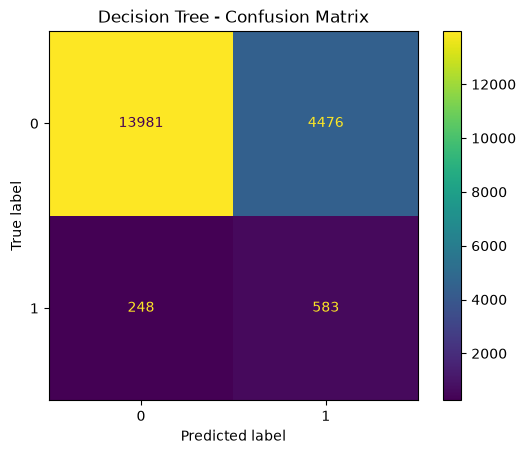

In [456]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt


# =========================
# Decision Tree Classifier
# =========================

model_dt = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

model_dt.fit(
    x_train_processed,
    y_train
)


# =========================
# Prediction
# =========================

y_pred = model_dt.predict(x_test_processed)

y_prob = model_dt.predict_proba(
    x_test_processed
)[:, 1]


# =========================
# Evaluation
# =========================

print("========== Classification Report ==========")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


print("========== Confusion Matrix ==========")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


print("========== ROC-AUC ==========")

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)


# =========================
# Plot Confusion Matrix
# =========================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [458]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. Create the Classification Model
# ============================================================

clf = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=7,
    min_samples_leaf=20,
    random_state=42
)

# ============================================================
# 2. Train the Model
# ============================================================

clf.fit(x_train_processed, y_train)

# ============================================================
# 3. Default Predictions (Threshold = 0.5)
# ============================================================

y_pred = clf.predict(x_test_processed)

print("========== Classification Report ==========")
print(classification_report(y_test, y_pred))

print("========== Confusion Matrix ==========")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# 4. ROC-AUC
# ============================================================

y_proba = clf.predict_proba(x_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print("========== ROC-AUC ==========")
print(roc_auc)

# ============================================================
# 5. Threshold Analysis
# ============================================================

print("\n========== Threshold Analysis ==========")

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

========== Classification Report ==========
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     18457
           1       0.12      0.70      0.20       831

    accuracy                           0.76     19288
   macro avg       0.55      0.73      0.53     19288
weighted avg       0.95      0.76      0.83     19288

========== Confusion Matrix ==========
[[13981  4476]
 [  248   583]]
========== ROC-AUC ==========
0.7782030461148614

========== Threshold Analysis ==========
Threshold=0.10 | Precision=0.050 | Recall=0.957 | F1=0.095
Threshold=0.15 | Precision=0.053 | Recall=0.942 | F1=0.101
Threshold=0.20 | Precision=0.060 | Recall=0.911 | F1=0.112
Threshold=0.25 | Precision=0.065 | Recall=0.886 | F1=0.122
Threshold=0.30 | Precision=0.068 | Recall=0.864 | F1=0.126
Threshold=0.35 | Precision=0.085 | Recall=0.793 | F1=0.154
Threshold=0.40 | Precision=0.090 | Recall=0.773 | F1=0.161
Threshold=0.45 | Precision=0.104 | Recall=0.746 | F1=0.